### Customer Churn Predictions

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### Problem Statements: 
Develop a machine learning model to predict customer churn by analyzing customer data and identifying customers who are likely to discontinue the service.



### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- The raw data contains 7043 rows (customers) and 21 columns (features).
- The “Churn” column is our target.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame


In [70]:
df=pd.read_csv(r'C:\Users\koiri\OneDrive\Desktop\Customer Churn Prediction\notebook\data\Telco Customer Churn.csv')

Show Top 5 records

In [71]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Shape of the datasets

In [72]:
df.shape

(7043, 21)

### 2.2 Dataset information


#### The data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents 
    

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Checking Missing Values

In [73]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### There are no missing values in the data set


### 3.2 Check Duplicates


In [74]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicate values in the dataset

### 3.3 Check DataTypes

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 3.4 Checking the number of unique values of each column


In [76]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

### 3.5 Check statistics of data set


In [77]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Insights

- Only 16.2% of customers are senior citizens, indicating that the customer base is predominantly composed of non-senior customers.
- Customer tenure varies significantly, with an average of 32 months and a range from 0 to 72 months, showing a mix of new and long-term customers.
- Monthly charges range from 18.25 to 118.75, suggesting the presence of multiple service plans, from basic to premium subscriptions.

### 3.7 Exploring Data


In [78]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_features = df.select_dtypes(include=['object', 'string']).columns.tolist()


print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 3 numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
We have 18 categorical features: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [79]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [80]:
df=df.drop('customerID', axis=1)

In [81]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

### Converting TotalCharges -> from str to float

- Used errors='coerce' for making invalid values to NAN

In [83]:
pd.to_numeric(df['TotalCharges'], errors='coerce').isna()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: TotalCharges, Length: 7043, dtype: bool

Removing the rows with NAN 

In [84]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna(subset=['TotalCharges'])

In [85]:
print("\nInvalid TotalCharges:")
print(pd.to_numeric(df['TotalCharges'], errors='coerce').isna().sum())


Invalid TotalCharges:
0


In [86]:
df.shape

(7032, 20)

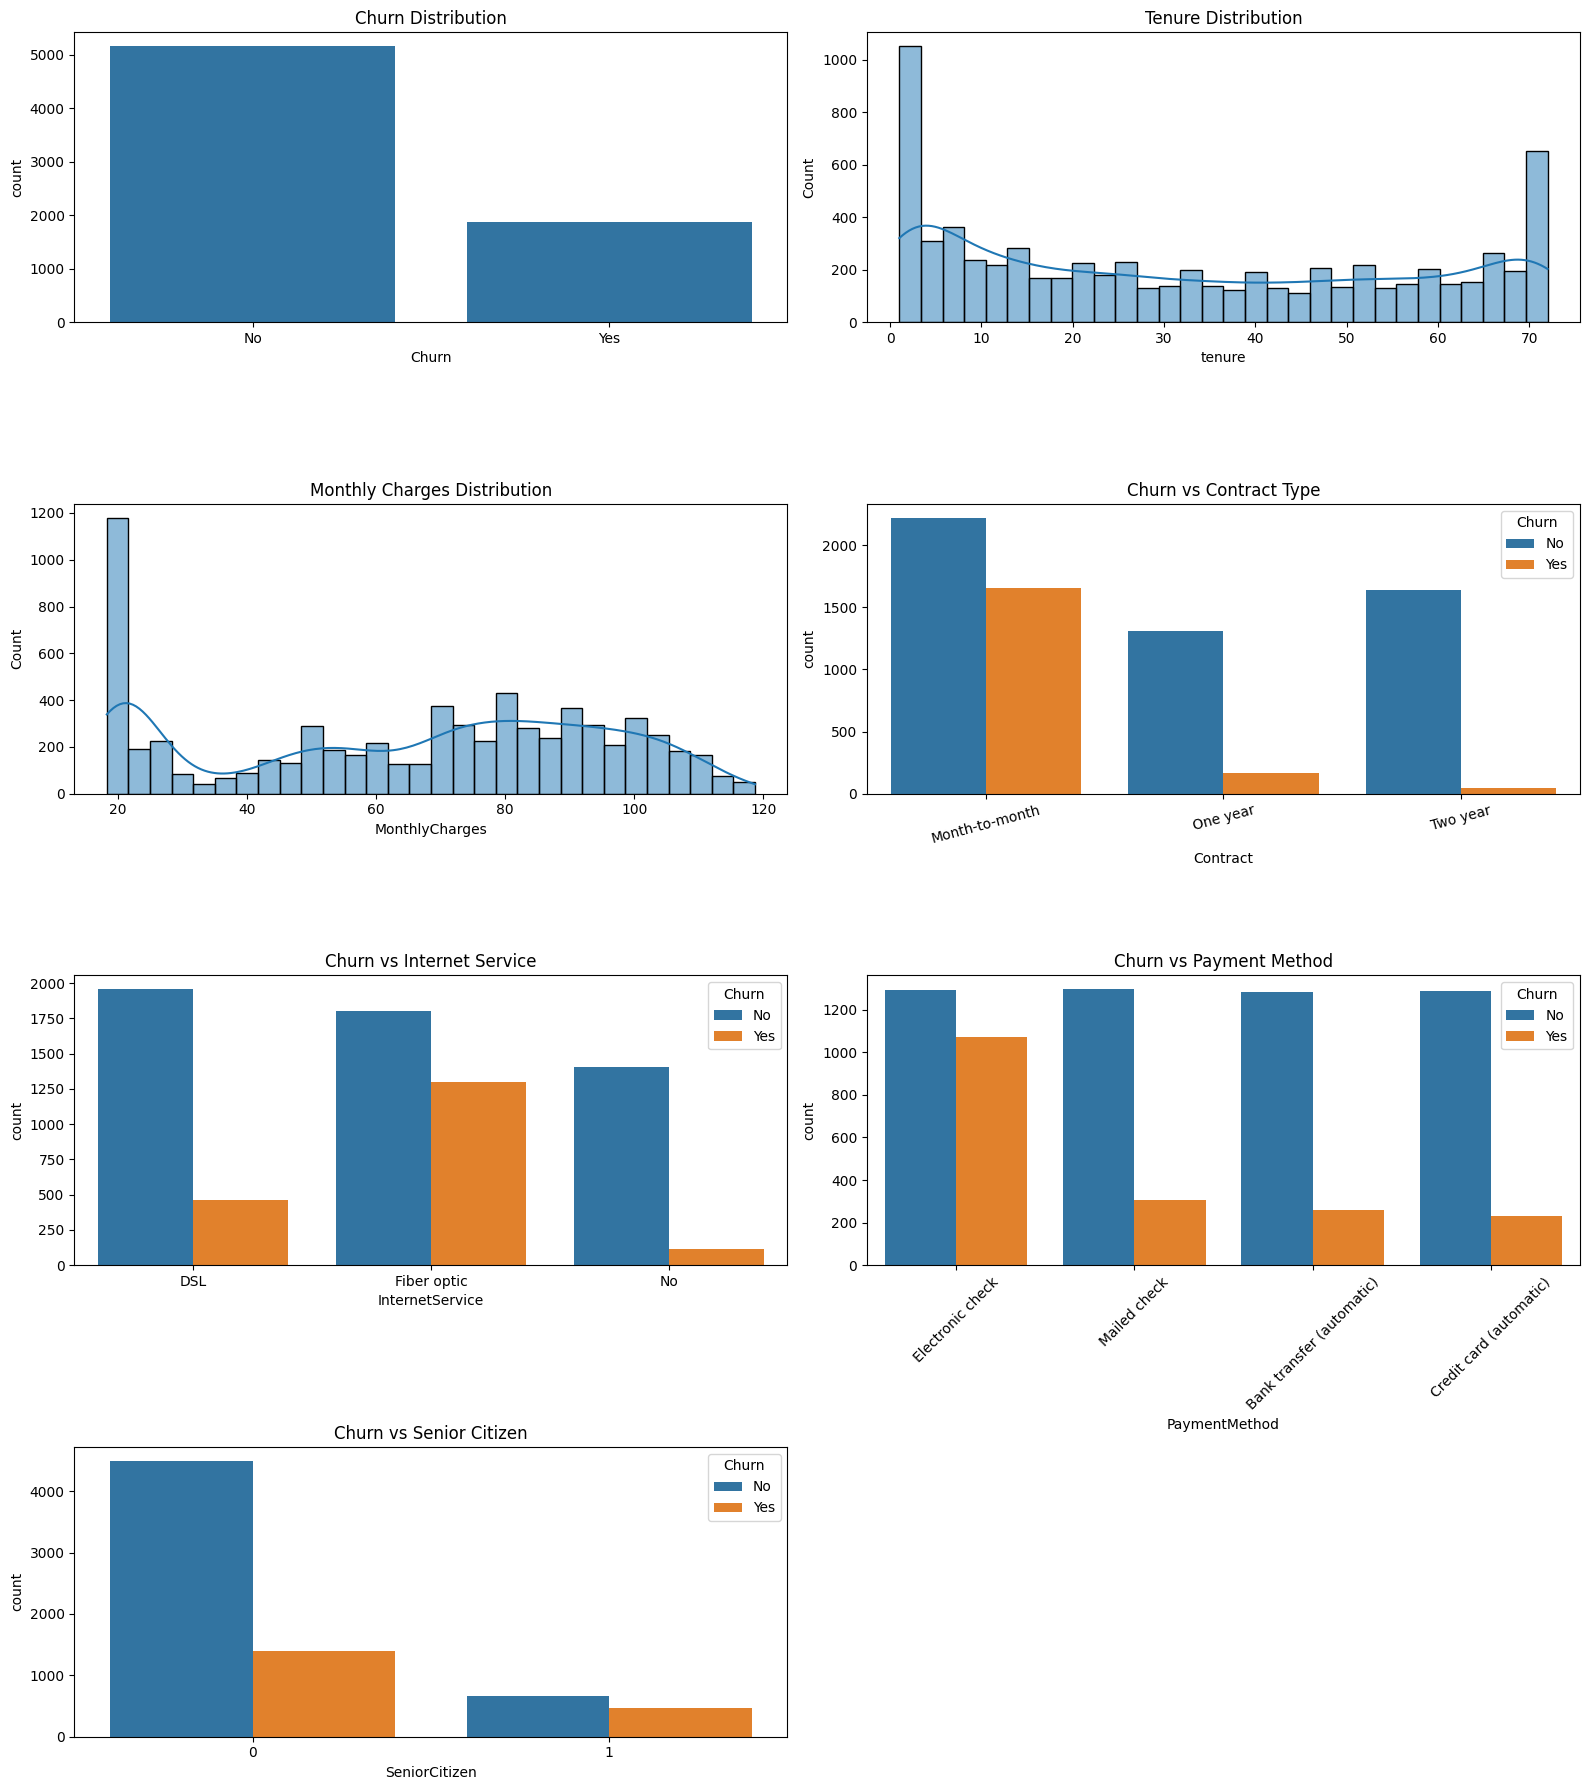

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

# 1. Churn Distribution
sns.countplot(x='Churn', data=df, ax=axes[0])
axes[0].set_title('Churn Distribution')

# 2. Tenure Distribution
sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Tenure Distribution')

# 3. Monthly Charges Distribution
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Monthly Charges Distribution')

# 4. Churn vs Contract Type
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[3])
axes[3].set_title('Churn vs Contract Type')
axes[3].tick_params(axis='x', rotation=15)

# 5. Churn vs Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[4])
axes[4].set_title('Churn vs Internet Service')

# 6. Churn vs Payment Method
sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[5])
axes[5].set_title('Churn vs Payment Method')
axes[5].tick_params(axis='x', rotation=45)

# 7. Churn vs Senior Citizen
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, ax=axes[6])
axes[6].set_title('Churn vs Senior Citizen')



# Remove empty subplot
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

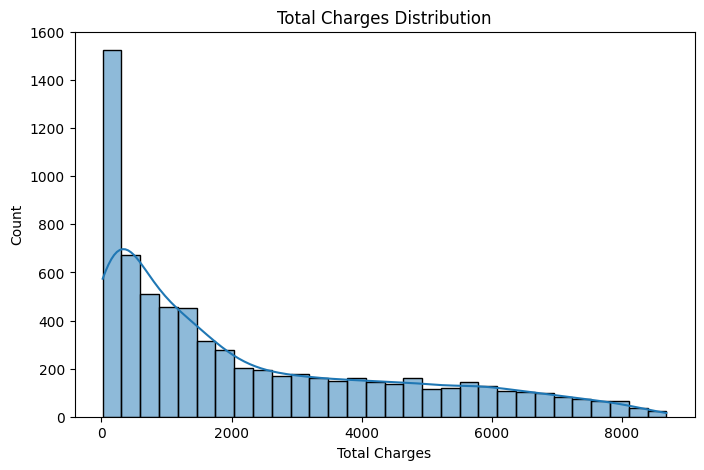

In [88]:
plt.figure(figsize=(8,5))
sns.histplot(df['TotalCharges'], bins=30, kde=True)
plt.title('Total Charges Distribution')
plt.xlabel('Total Charges')
plt.show()

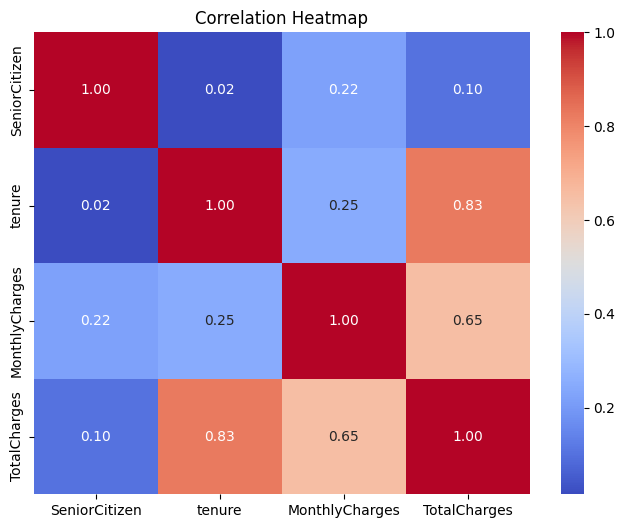

In [89]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

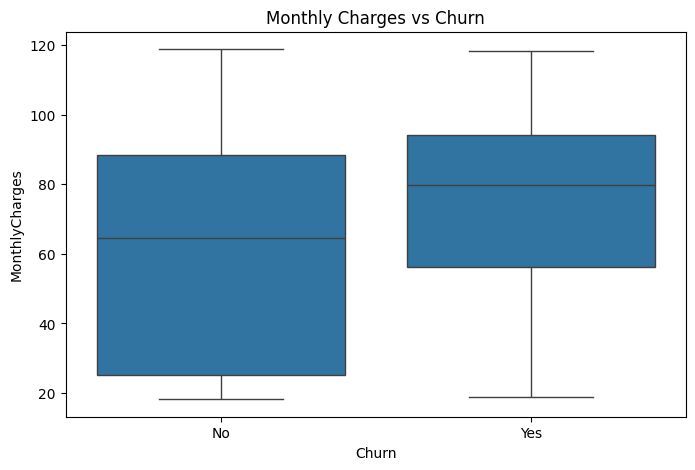

In [90]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

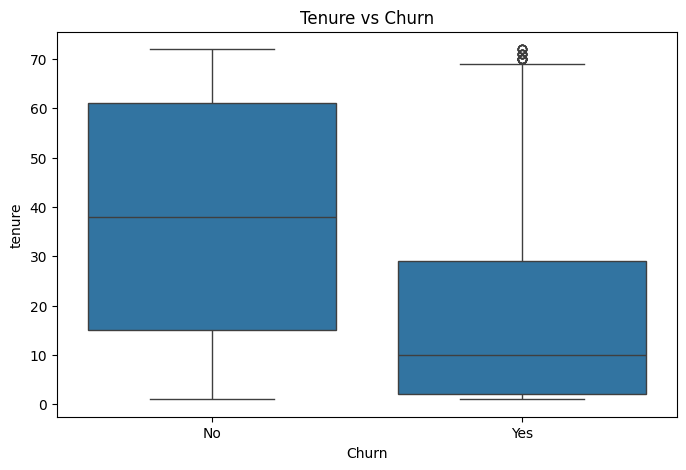

In [91]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

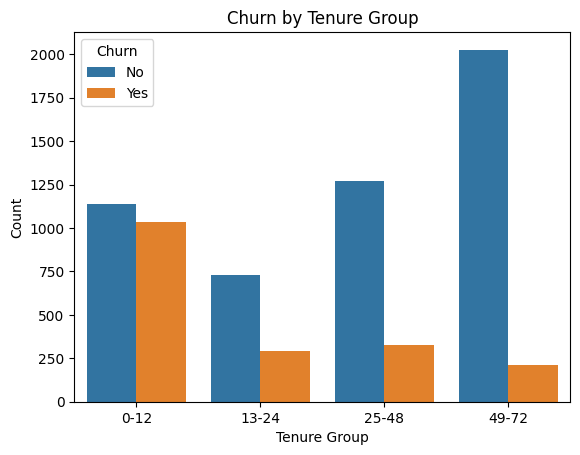

In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x=pd.cut(
        df['tenure'],
        bins=[0, 12, 24, 48, 72],
        labels=['0-12', '13-24', '25-48', '49-72']
    ),
    hue=df['Churn']
)

plt.title('Churn by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Count')
plt.show()

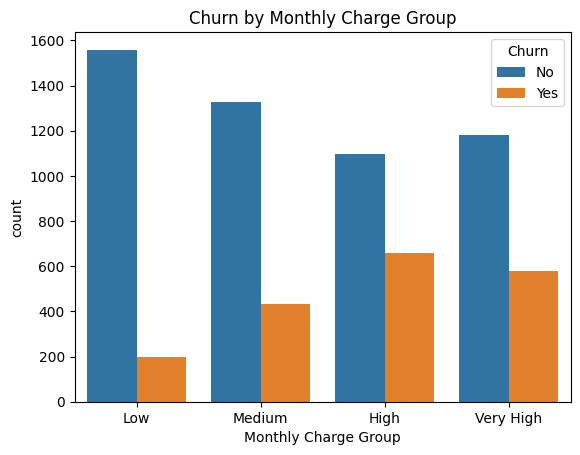

In [93]:
sns.countplot(
    x=pd.qcut(
        df['MonthlyCharges'],
        q=4,
        labels=['Low', 'Medium', 'High', 'Very High']
    ),
    hue=df['Churn']
)

plt.title('Churn by Monthly Charge Group')
plt.xlabel('Monthly Charge Group')
plt.show()

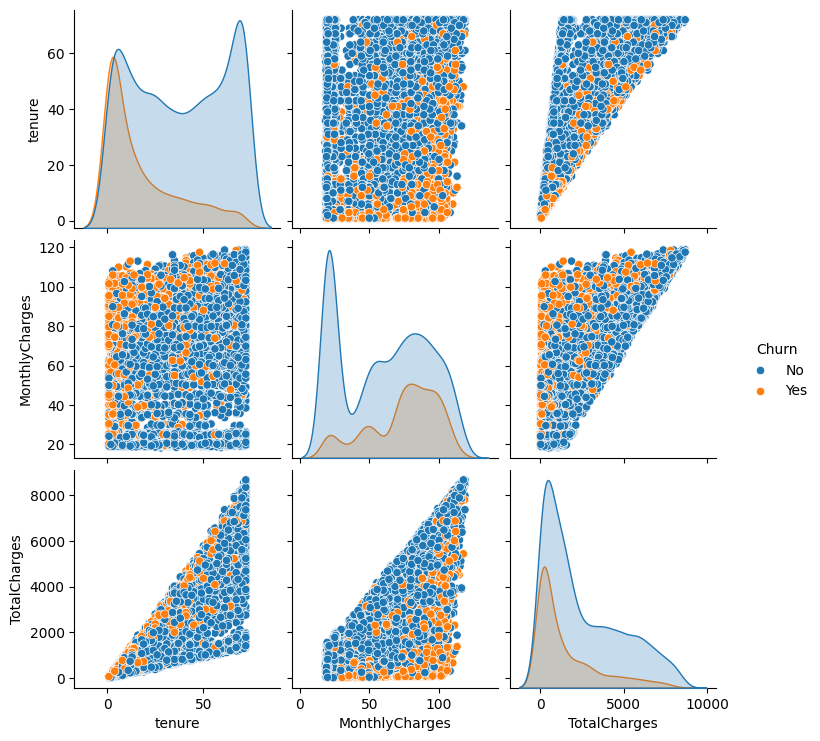

In [94]:
sns.pairplot(
    df[['tenure','MonthlyCharges','TotalCharges','Churn']],
    hue='Churn'
)
plt.show()

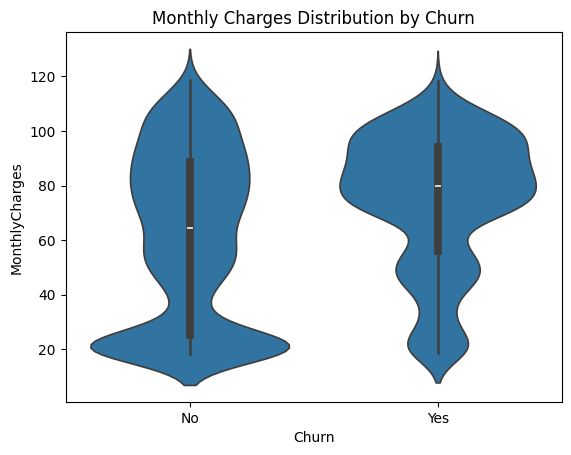

In [95]:
sns.violinplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)
plt.title('Monthly Charges Distribution by Churn')
plt.show()

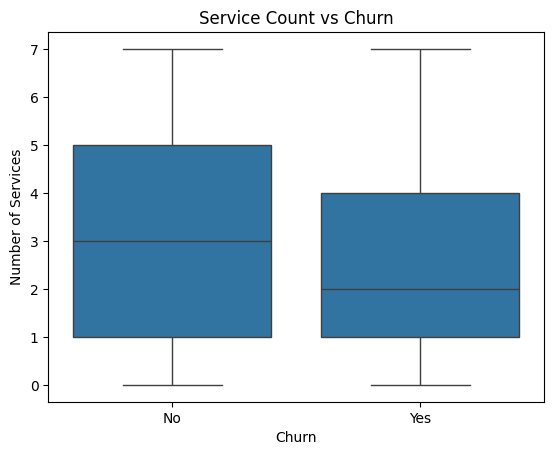

In [96]:
services = [
    'PhoneService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

service_count = (
    df[services]
    .replace({
        'Yes': 1,
        'No': 0,
        'No internet service': 0,
        'No phone service': 0
    })
    .sum(axis=1)
)

sns.boxplot(
    x=df['Churn'],
    y=service_count
)

plt.title('Service Count vs Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Services')
plt.show()

In [97]:
df.to_csv("customer_churn_cleaned.csv", index=False)